# 04 — Phân tích trên toàn bộ dữ liệu: bảng Gold + hệ số tương quan

**Mốc pipeline:** Silver → **Gold** — mọi bảng ở đây tính trên **toàn bộ ~82 triệu dòng** bằng Spark.

1. Các bảng tổng hợp (Gold) trả lời câu hỏi: *đặt sớm hay đi gấp thì giá thế nào?* và các yếu tố khác.
2. **Hệ số tương quan** giữa giá vé và từng chỉ số (Pearson trên toàn bộ dữ liệu, Spearman trên mẫu,
   tỉ số tương quan η cho biến phân loại) → **chọn chỉ số đưa vào huấn luyện** ở notebook 05.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))
from common import *
from viz import *
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

spark = get_spark("04-gold")
silver = spark.read.parquet(SILVER)      # Parquet dạng cột: mỗi phép tổng hợp chỉ đọc vài cột cần thiết
N = silver.count()
print(f"Silver: {N:,} dòng")

Silver: 82,137,463 dòng


## 1. Tổng quan

In [2]:
kpi = silver.agg(
    F.count("*").alias("so_ve"), F.countDistinct("legId").alias("so_chuyen_bay"),
    F.countDistinct("route").alias("so_tuyen"), F.countDistinct("airline_name").alias("so_hang"),
    F.round(F.avg("totalFare"), 2).alias("gia_tb"),
    F.round(F.percentile_approx("totalFare", 0.5), 2).alias("gia_trung_vi"),
    F.min("searchDate").alias("tim_tu"), F.max("searchDate").alias("tim_den"),
    F.min("flightDate").alias("bay_tu"), F.max("flightDate").alias("bay_den"),
).toPandas().T.rename(columns={0: "giá trị"})
kpi.to_csv(f"{EXPORTS}/04_kpi.csv")
kpi

,giá trị
so_ve,82137463
so_chuyen_bay,5999739
so_tuyen,234
so_hang,14
gia_tb,340.39
gia_trung_vi,305.2
tim_tu,2022-04-16
tim_den,2022-10-05
bay_tu,2022-04-17
bay_den,2022-11-19


## 2. Các bảng Gold

In [3]:
def agg_price(df, *keys):
    return (df.groupBy(*keys)
              .agg(F.count("*").alias("n"),
                   F.round(F.avg("totalFare"), 2).alias("avg_fare"),
                   F.round(F.percentile_approx("totalFare", 0.25), 2).alias("p25_fare"),
                   F.round(F.percentile_approx("totalFare", 0.5), 2).alias("median_fare"),
                   F.round(F.percentile_approx("totalFare", 0.75), 2).alias("p75_fare"))
              .orderBy(*keys))

gold_specs = {
    "by_days_before": ("days_before",),
    "by_booking_window": ("booking_window",),
    "by_window_airline": ("airline_name", "booking_window"),
    "by_window_route": ("route", "booking_window"),
    "by_window_stops": ("num_stops", "booking_window"),
    "by_window_holiday": ("holiday_window", "booking_window"),
    "by_flight_date": ("flightDate",),
    "by_search_date": ("searchDate",),
    "by_flight_month": ("flight_month",),
    "by_day_of_week": ("day_of_week",),
    "by_search_dow": ("search_dow",),
    "by_dep_hour": ("dep_hour",),
    "by_airline": ("airline_name",),
    "by_stops": ("num_stops",),
    "by_cabin": ("cabin_level",),
    "by_basic_economy": ("basic_economy",),
    "by_seats": ("seatsRemaining",),
    "by_days_to_holiday": ("days_to_holiday",),
    "by_origin_bad_weather": ("origin_bad_weather",),
    "by_route": ("route",),
    "by_origin": ("startingAirport",),
}
gold = {}
for name, keys in gold_specs.items():
    df = agg_price(silver, *keys)
    df.write.mode("overwrite").parquet(f"{GOLD}/{name}")
    gold[name] = df.toPandas()
    gold[name].to_csv(f"{EXPORTS}/gold_{name}.csv", index=False)
print({k: len(v) for k, v in gold.items()})

{'by_days_before': 60, 'by_booking_window': 3, 'by_window_airline': 42, 'by_window_route': 702, 'by_window_stops': 15, 'by_window_holiday': 6, 'by_flight_date': 217, 'by_search_date': 171, 'by_flight_month': 8, 'by_day_of_week': 7, 'by_search_dow': 7, 'by_dep_hour': 21, 'by_airline': 14, 'by_stops': 5, 'by_cabin': 4, 'by_basic_economy': 2, 'by_seats': 11, 'by_days_to_holiday': 75, 'by_origin_bad_weather': 2, 'by_route': 234, 'by_origin': 16}


## 3. Đặt sớm hay đi gấp?

In [4]:
bw = gold["by_booking_window"].copy()
base = bw.loc[bw.booking_window.str.startswith("3"), "median_fare"].iloc[0]
bw["chenh_lech_vs_dat_som_%"] = ((bw.median_fare / base - 1) * 100).round(1)
bw

,booking_window,n,avg_fare,p25_fare,median_fare,p75_fare,chenh_lech_vs_dat_som_%
0,1. Rất gấp (1-7 ngày),11940588,369.30,238.60,342.60,462.60,18.9
1,2. Gấp (8-30 ngày),35732869,341.74,197.10,305.61,456.10,6.1
2,3. Sớm (31-60 ngày),34464006,328.97,181.58,288.10,446.59,0.0


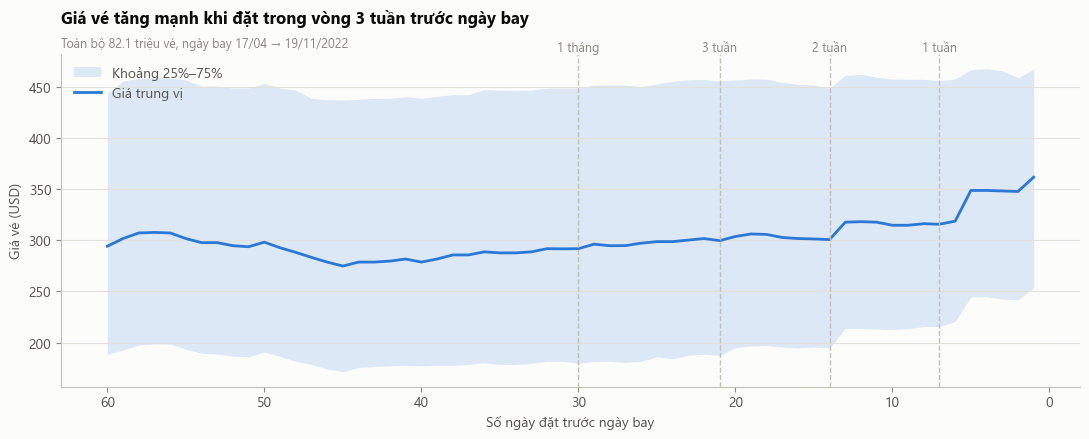

In [5]:
d = gold["by_days_before"].query("days_before >= 1")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(d.days_before, d.p25_fare, d.p75_fare, color=SERIES[0], alpha=0.15, linewidth=0, label="Khoảng 25%–75%")
ax.plot(d.days_before, d.median_fare, color=SERIES[0], label="Giá trung vị")
for x, txt in [(7, "1 tuần"), (14, "2 tuần"), (21, "3 tuần"), (30, "1 tháng")]:
    ax.axvline(x, color=AXIS, linewidth=1, linestyle="--")
    ax.text(x, ax.get_ylim()[1], txt, color=MUTED, fontsize=9, ha="center", va="bottom")
ax.invert_xaxis()
ax.set(xlabel="Số ngày đặt trước ngày bay", ylabel="Giá vé (USD)")
ax.set_title("Giá vé tăng mạnh khi đặt trong vòng 3 tuần trước ngày bay", pad=22)
note(ax, f"Toàn bộ {N/1e6:.1f} triệu vé, ngày bay 17/04 → 19/11/2022")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_04_booking_curve.png", dpi=150); plt.show()

In [6]:
# Mức đội giá khi đi gấp theo hãng và theo tuyến (trung vị 'Gấp 8–30' và 'Rất gấp 1–7' so với 'Sớm 31–60')
def premium(table, key, min_n=20000):
    p = table.pivot_table(index=key, columns="booking_window", values="median_fare")
    n = table.groupby(key)["n"].sum()
    p.columns = ["rat_gap", "gap", "som"]
    p["premium_gap_%"] = ((p.gap / p.som - 1) * 100).round(1)
    p["premium_rat_gap_%"] = ((p.rat_gap / p.som - 1) * 100).round(1)
    p["n"] = n
    return p[p.n >= min_n].sort_values("premium_rat_gap_%")

prem_airline = premium(gold["by_window_airline"], "airline_name")
prem_route = premium(gold["by_window_route"], "route")
prem_airline.to_csv(f"{EXPORTS}/04_urgency_premium_airline.csv")
prem_route.to_csv(f"{EXPORTS}/04_urgency_premium_route.csv")
prem_airline

,rat_gap,gap,som,premium_gap_%,premium_rat_gap_%,n
airline_name,,,,,,
United,358.60,347.61,347.61,0.0,3.2,19042393
Delta,394.11,370.60,357.20,3.8,10.3,20474356
Alaska Airlines,541.20,492.20,467.11,5.4,15.9,4111647
Cape Air,503.92,471.92,432.41,9.1,16.5,37286
American Airlines,304.11,278.60,257.61,8.1,18.1,25026718
Boutique Air,513.40,456.40,430.91,5.9,19.1,24447
Sun Country Airlines,449.60,403.60,360.60,11.9,24.7,223449
JetBlue Airways,270.10,228.60,215.60,6.0,25.3,6821762
Key Lime Air,392.40,342.40,302.41,13.2,29.8,25137


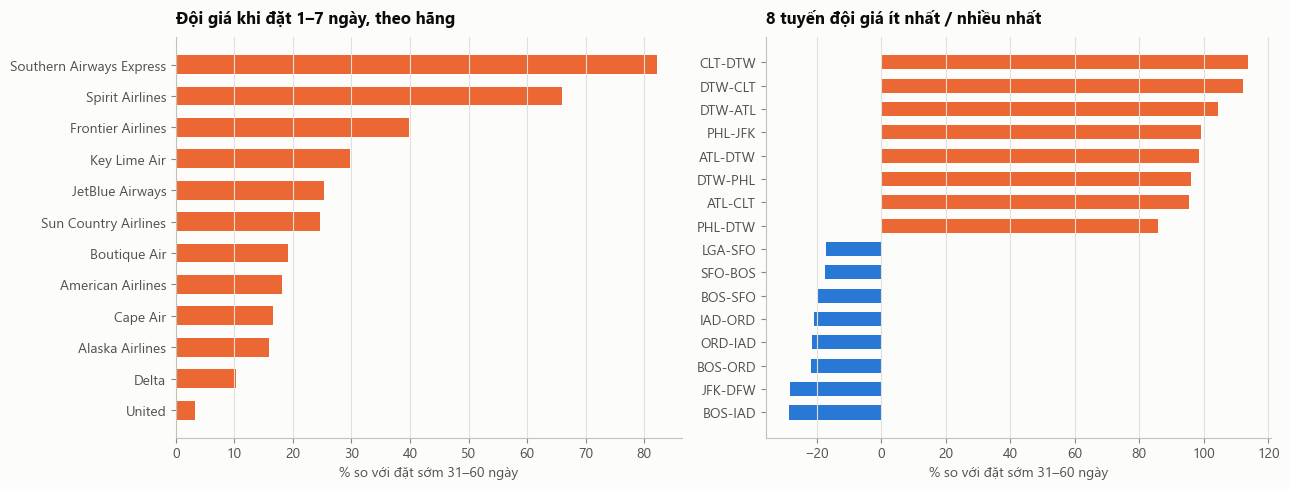

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
a = prem_airline
axes[0].barh(a.index, a["premium_rat_gap_%"], color=SERIES[1], height=0.6)
axes[0].set_title("Đội giá khi đặt 1–7 ngày, theo hãng"); axes[0].set_xlabel("% so với đặt sớm 31–60 ngày")
axes[0].grid(axis="x"); axes[0].grid(axis="y", visible=False)
r = pd.concat([prem_route.head(8), prem_route.tail(8)])
axes[1].barh(r.index, r["premium_rat_gap_%"], color=[SERIES[0]] * 8 + [SERIES[1]] * 8, height=0.6)
axes[1].set_title("8 tuyến đội giá ít nhất / nhiều nhất"); axes[1].set_xlabel("% so với đặt sớm 31–60 ngày")
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_04_urgency_premium.png", dpi=150); plt.show()

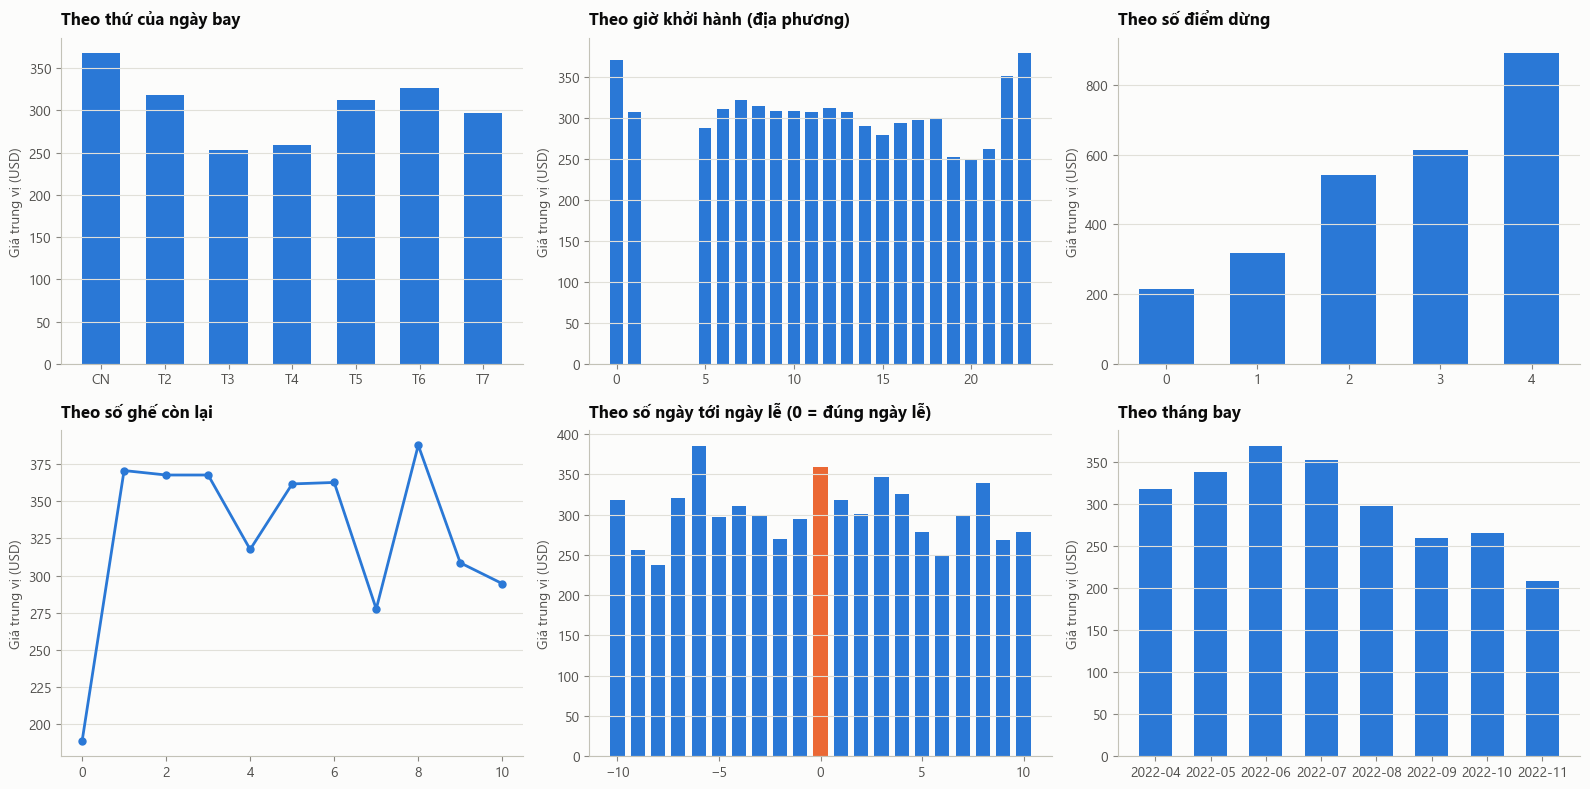

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
lab = ["CN", "T2", "T3", "T4", "T5", "T6", "T7"]
d = gold["by_day_of_week"]; axes[0, 0].bar([lab[i - 1] for i in d.day_of_week], d.median_fare, color=SERIES[0], width=0.6)
axes[0, 0].set_title("Theo thứ của ngày bay")
d = gold["by_dep_hour"].dropna(); axes[0, 1].bar(d.dep_hour, d.median_fare, color=SERIES[0], width=0.7)
axes[0, 1].set_title("Theo giờ khởi hành (địa phương)")
d = gold["by_stops"]; axes[0, 2].bar(d.num_stops.astype(str), d.median_fare, color=SERIES[0], width=0.6)
axes[0, 2].set_title("Theo số điểm dừng")
d = gold["by_seats"]; axes[1, 0].plot(d.seatsRemaining, d.median_fare, marker="o", color=SERIES[0])
axes[1, 0].set_title("Theo số ghế còn lại")
d = gold["by_days_to_holiday"].query("abs(days_to_holiday) <= 10")
axes[1, 1].bar(d.days_to_holiday, d.median_fare, color=[SERIES[1] if x == 0 else SERIES[0] for x in d.days_to_holiday], width=0.7)
axes[1, 1].set_title("Theo số ngày tới ngày lễ (0 = đúng ngày lễ)")
d = gold["by_flight_month"]; axes[1, 2].bar(d.flight_month, d.median_fare, color=SERIES[0], width=0.6)
axes[1, 2].set_title("Theo tháng bay")
for ax in axes.flat: ax.set_ylabel("Giá trung vị (USD)")
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_04_factors.png", dpi=150); plt.show()

## 4. Hệ số tương quan — chọn chỉ số đưa vào huấn luyện

- **Pearson** (tuyến tính) trên **toàn bộ** dữ liệu bằng `pyspark.ml.stat.Correlation`.
- **Spearman** (đơn điệu, ít nhạy với giá ngoại lai) trên mẫu 3% — Spearman phải xếp hạng từng cột nên tốn kém.
- Với cả giá vé gốc `totalFare` và `log(totalFare)` (giá vé lệch phải mạnh).

In [9]:
NUM_FEATURES = [
    # thời điểm đặt / bay
    "days_before", "search_dow", "month", "week_of_year", "day_of_week", "is_weekend", "dep_hour",
    # hành trình
    "duration_min", "num_stops", "multi_airline", "cabin_level", "basic_economy", "refundable", "non_stop",
    "seatsRemaining", "totalTravelDistance", "elapsedDays", "cross_region", "lat_diff",
    # ngày lễ
    "is_holiday", "holiday_window", "days_to_holiday",
    # thời tiết
    "origin_temp_mean", "origin_precip_mm", "origin_snow_cm", "origin_wind_max", "origin_bad_weather",
    "dest_temp_mean", "dest_precip_mm", "dest_bad_weather",
    # vĩ mô: nhiên liệu, CPI, lạm phát
    "jet_fuel_usd_gal", "fuel_7d_change", "cpi_all", "cpi_airfare", "inflation_yoy", "airfare_yoy",
]
cols = ["totalFare", "log_fare"] + NUM_FEATURES
corr_df = silver.withColumn("log_fare", F.log("totalFare")).select(*[F.col(c).cast("double") for c in cols])
vec = VectorAssembler(inputCols=cols, outputCol="v", handleInvalid="skip").transform(corr_df).select("v")

pearson = Correlation.corr(vec, "v", "pearson").head()[0].toArray()
spearman = Correlation.corr(vec.sample(0.03, seed=SEED), "v", "spearman").head()[0].toArray()

corr = pd.DataFrame({
    "pearson_fare": pearson[0, 2:], "pearson_logfare": pearson[1, 2:],
    "spearman_fare": spearman[0, 2:],
}, index=NUM_FEATURES).round(4)
corr["abs_max"] = corr.abs().max(axis=1)
corr = corr.sort_values("abs_max", ascending=False)
pd.DataFrame(pearson, index=cols, columns=cols).round(4).to_csv(f"{EXPORTS}/04_pearson_matrix.csv")
corr.to_csv(f"{EXPORTS}/04_correlation_with_fare.csv")
corr

,pearson_fare,pearson_logfare,spearman_fare,abs_max
totalTravelDistance,0.4926,0.5231,0.5232,0.5232
duration_min,0.4791,0.5103,0.5166,0.5166
basic_economy,-0.3696,-0.4527,-0.4491,0.4527
multi_airline,0.4166,0.4052,0.4459,0.4459
num_stops,0.4071,0.4339,0.4317,0.4339
non_stop,-0.2964,-0.3533,-0.3489,0.3533
cross_region,0.2843,0.3162,0.3133,0.3162
cabin_level,0.2275,0.1013,0.0690,0.2275
week_of_year,-0.1754,-0.1912,-0.1986,0.1986
month,-0.1706,-0.1854,-0.1921,0.1921


### Biến phân loại: tỉ số tương quan η (eta)

η² = phần phương sai của giá vé được giải thích bởi nhóm (tuyến, hãng, sân bay...). η nằm trong [0, 1].

In [10]:
overall = silver.agg(F.avg("totalFare").alias("m"), F.variance("totalFare").alias("v"), F.count("*").alias("n")).first()
eta = {}
for c in ["route", "airline_code", "startingAirport", "destinationAirport", "booking_window",
          "origin_region", "dest_region", "fareBasisCode"]:
    g = silver.groupBy(c).agg(F.count("*").alias("n"), F.avg("totalFare").alias("m")).toPandas()
    ss_between = (g.n * (g.m - overall.m) ** 2).sum()
    eta[c] = np.sqrt(ss_between / (overall.v * (overall.n - 1)))
eta = pd.Series(eta, name="eta").sort_values(ascending=False).round(4)
eta.to_csv(f"{EXPORTS}/04_eta_categorical.csv")
eta

fareBasisCode         0.8309
route                 0.5682
airline_code          0.3307
startingAirport       0.3064
destinationAirport    0.2745
origin_region         0.2480
dest_region           0.2002
booking_window        0.0679
Name: eta, dtype: float64

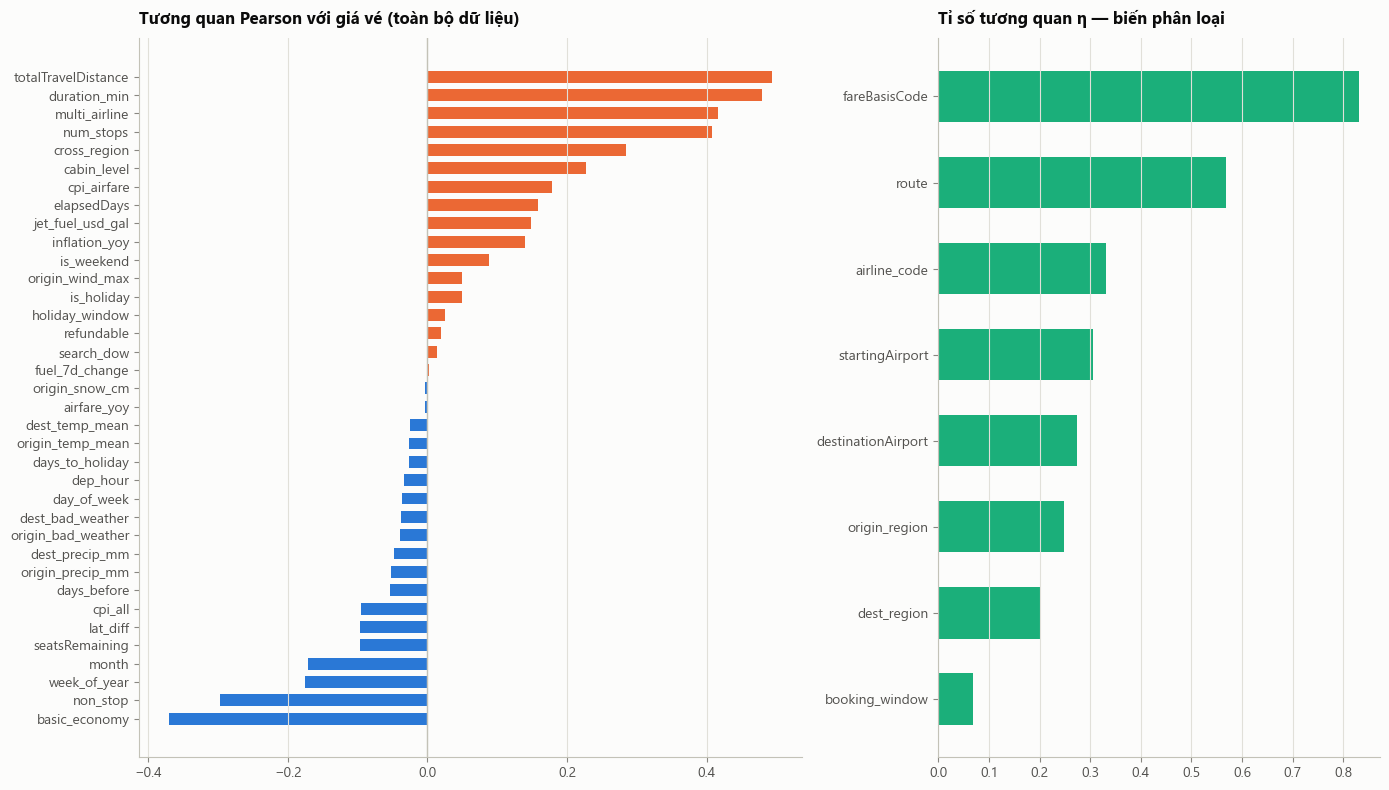

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [3, 2]})
c = corr.sort_values("pearson_fare")
axes[0].barh(c.index, c.pearson_fare, color=[SERIES[1] if v > 0 else SERIES[0] for v in c.pearson_fare], height=0.65)
axes[0].axvline(0, color=AXIS, linewidth=1)
axes[0].set_title("Tương quan Pearson với giá vé (toàn bộ dữ liệu)")
axes[0].grid(axis="x"); axes[0].grid(axis="y", visible=False)
e = eta.sort_values()
axes[1].barh(e.index, e.values, color=SERIES[2], height=0.6)
axes[1].set_title("Tỉ số tương quan η — biến phân loại")
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(f"{EXPORTS}/fig_04_correlation.png", dpi=150); plt.show()

### Chọn chỉ số cho mô hình

Quy tắc:
1. Giữ biến số có |Pearson| hoặc |Spearman| ≥ **0.05** với giá vé (hoặc log giá vé).
2. Giữ biến phân loại có η ≥ **0.10** (trừ `fareBasisCode` — mã giá gần như là "đáp án", gây rò rỉ dữ liệu).
3. Bỏ bớt một trong hai biến **trùng thông tin** (|r| giữa hai biến > 0.9), giữ biến tương quan với giá mạnh hơn.
4. Luôn giữ `days_before` vì đó là trục chính của bài toán (đặt sớm / đi gấp).

In [12]:
pm = pd.DataFrame(pearson, index=cols, columns=cols)
cand = [f for f in corr.index if corr.loc[f, "abs_max"] >= 0.05 or f == "days_before"]
selected, dropped = [], {}
for f in cand:                               # đã sắp theo |tương quan| giảm dần
    dup = [s for s in selected if abs(pm.loc[f, s]) > 0.9]
    if dup:
        dropped[f] = f"trùng thông tin với {dup[0]} (r = {pm.loc[f, dup[0]]:.2f})"
    else:
        selected.append(f)
for f in NUM_FEATURES:
    if f not in cand:
        dropped[f] = f"tương quan yếu (|r| max = {corr.loc[f, 'abs_max']:.3f})"
cat_selected = [c for c in eta.index if eta[c] >= 0.10 and c not in ("fareBasisCode", "booking_window")]

selection = {"numeric": selected, "categorical": cat_selected, "dropped": dropped}
json.dump(selection, open(f"{GOLD}/feature_selection.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print("Biến số được chọn:", selected)
print("Biến phân loại được chọn:", cat_selected)
pd.Series(dropped, name="lý do loại").to_frame()

Biến số được chọn: ['totalTravelDistance', 'duration_min', 'basic_economy', 'multi_airline', 'num_stops', 'non_stop', 'cross_region', 'cabin_level', 'week_of_year', 'cpi_airfare', 'elapsedDays', 'jet_fuel_usd_gal', 'inflation_yoy', 'seatsRemaining', 'cpi_all', 'lat_diff', 'is_weekend', 'origin_precip_mm', 'days_before', 'dest_precip_mm', 'origin_wind_max', 'is_holiday']
Biến phân loại được chọn: ['route', 'airline_code', 'startingAirport', 'destinationAirport', 'origin_region', 'dest_region']


,lý do loại
month,trùng thông tin với week_of_year (r = 0.98)
search_dow,tương quan yếu (|r| max = 0.016)
day_of_week,tương quan yếu (|r| max = 0.037)
dep_hour,tương quan yếu (|r| max = 0.039)
refundable,tương quan yếu (|r| max = 0.020)
holiday_window,tương quan yếu (|r| max = 0.027)
days_to_holiday,tương quan yếu (|r| max = 0.030)
origin_temp_mean,tương quan yếu (|r| max = 0.030)
origin_snow_cm,tương quan yếu (|r| max = 0.011)
origin_bad_weather,tương quan yếu (|r| max = 0.041)


**Ghi chú về lạm phát:** trong 7 tháng của dữ liệu 2022, CPI và lạm phát chỉ thay đổi theo tháng
(≈ 6 giá trị khác nhau) nên tương quan theo từng vé bị lẫn với mùa vụ. Tác động thật của lạm phát và nhiên liệu
lên giá vé được đo ở **notebook 06** trên chuỗi số liệu nhiều năm (2005 → 2026).